## **Notebook 5: `Country-Level Hourly Rate Insights`**

## **Importing libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

## **2. Loading hourly jobs**

In [2]:
hourly_df = pd.read_csv(r"D:\Project 8\hourly_jobs.csv")
hourly_df.head()

,title,link,published_date,is_hourly,hourly_low,hourly_high,budget,country,clean_title,job_type,avg_hourly_rate,year,month,month_name,year_month,week
0,SMMA Bubble App,https://www.upwork.com/jobs/SMMA-Bubble-App_%7...,2024-02-17 09:08:46+00:00,True,10.0,30.0,NaN,United States,smma bubble app,Hourly,20.0,2024,2,February,2024-02,2024-02-12/2024-02-18
1,Talent Hunter Specialized in Marketing,https://www.upwork.com/jobs/Talent-Hunter-Spec...,2024-02-17 09:08:08+00:00,True,NaN,NaN,NaN,United States,talent hunter specialized in marketing,Hourly,NaN,2024,2,February,2024-02,2024-02-12/2024-02-18
2,SEO for Portuguese Psychologist site,https://www.upwork.com/jobs/SEO-for-Portuguese...,2024-02-17 09:07:41+00:00,True,NaN,NaN,NaN,Portugal,seo for portuguese psychologist site,Hourly,NaN,2024,2,February,2024-02,2024-02-12/2024-02-18
3,need Portuguese writers who can understand and...,https://www.upwork.com/jobs/need-Portuguese-wr...,2024-02-17 09:07:05+00:00,True,7.0,22.0,NaN,India,need portuguese writers who can understand and...,Hourly,14.5,2024,2,February,2024-02,2024-02-12/2024-02-18
4,Looker Studio Dashboard for Leadgen and E-Comm...,https://www.upwork.com/jobs/Looker-Studio-Dash...,2024-02-17 09:06:24+00:00,True,NaN,NaN,NaN,Germany,looker studio dashboard for leadgen and e-comm...,Hourly,NaN,2024,2,February,2024-02,2024-02-12/2024-02-18


## **3. Group by country**

In [3]:
country_summary = (
    hourly_df.groupby("country")["avg_hourly_rate"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
)

## **4. Filter small samples**

In [4]:
country_summary = country_summary[country_summary["count"] >= 50]
country_summary = country_summary.sort_values("mean", ascending=False)
country_summary.head(20)

,country,count,mean,median,min,max
109,Malaysia,325,48.103077,22.5,3.5,235.0
178,Thailand,287,42.205575,22.5,3.5,160.0
93,Jordan,55,36.154545,22.5,4.0,501.5
190,United States,46620,32.582486,25.0,3.0,998.5
100,Latvia,106,32.391509,30.0,3.5,125.0
82,Hungary,148,32.317568,25.0,4.0,524.5
48,Cyprus,160,31.887500,25.0,4.0,550.0
95,Kenya,314,31.823248,26.0,3.5,175.0
15,Bangladesh,733,31.315825,20.0,3.5,501.0
39,Colombia,239,31.257322,22.5,3.0,503.5


## **5. Top countries visualization**

In [5]:
top_countries = country_summary.head(20)

fig = px.treemap(
    top_countries,
    path=["country"],
    values="mean",
    color="mean",
    color_continuous_scale="viridis",
    title="Country-wise Salary Distribution"
)

fig.show()

## **6. Job count vs average rate**

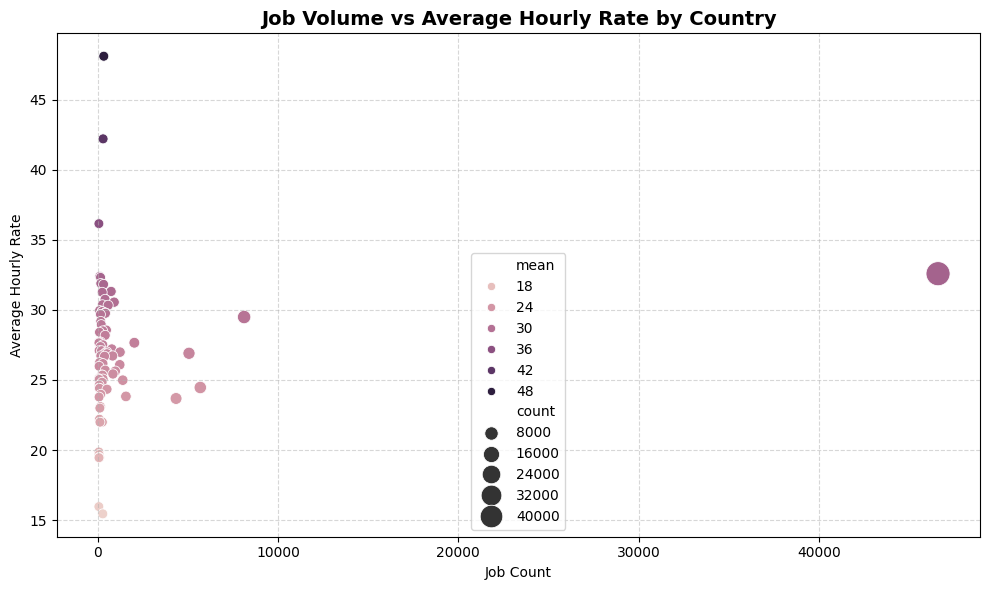

In [6]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=country_summary,
    x="count",
    y="mean",
    size="count",
    hue="mean",
    sizes=(50, 300)
)

plt.title("Job Volume vs Average Hourly Rate by Country", fontsize=14, weight='bold')
plt.xlabel("Job Count")
plt.ylabel("Average Hourly Rate")

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## **7. Saving summary**

In [7]:
country_summary.to_csv("country_hourly_summary.csv", index=False)